In [1]:
import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

import schwingerModel as sim

from schwingerModel.interpolator import MesonOp, mesonMultiplet, makeState

# from schwingerModel.distillation_gpu import generateDistillFile

def triplet(op):                      
    return mesonMultiplet(op, 1)[+1]

def singlet(op):                       
    return mesonMultiplet(op, 0)[0]

In [2]:
# every quark mass with its own list of volumes; everything downstream is keyed
# on the mass string. The finite-volume effect shrinks as the mass grows, so the
# m=0.2 scan stops at Nx=32 instead of repeating the expensive 48/64 boxes.
m0s = ["0.01", "0.02", "0.05", "0.2"]
Nxs = {"0.01": [8, 16, 32, 48, 64],
       "0.02": [8, 16, 32, 48, 64],
       "0.05": [8, 16, 32, 48, 64],
       "0.2":  [8, 16, 32]}

outPaths = {m0: [f"./configs/dwf_beta_3.0_m_{m0}_Nx_{Nx}_Nt_64_N5_16.hdf5" for Nx in Nxs[m0]]
            for m0 in m0s}

# the caches are now built by buildDistill.py on the gpu; numVecs is keyed on the
# volume so every mass gives the same box the same basis size. Kept here for
# reference — uncomment to rebuild in-notebook.
# paths = {m0: [f"./configs/dwf_beta_3.0_m_{m0}_Nx_{Nx}_Nt_64_N5_16.h5" for Nx in Nxs[m0]]
#          for m0 in m0s}
# numVecs = {8: 2, 16: 2, 32: 4, 48: 6, 64: 8}
# for m0 in m0s:
#     for i, Nx in enumerate(Nxs[m0]):
#         generateDistillFile(paths[m0][i], outPaths[m0][i], numVecs=numVecs[Nx],
#                             autocorrSkip=50, DNums=(0,2))

In [3]:
metas = {m0: [sim.distillation.readDistillMeta(p) for p in outPaths[m0]] for m0 in m0s}
beta, Nt = float(metas[m0s[0]][0].beta), metas[m0s[0]][0].dimt

In [4]:
pionBasis = [triplet(MesonOp("g5")),triplet(MesonOp("g5",DNum=2))]

In [5]:
pionCorrels = {m0: [sim.GEVP.measureEnsemble(outPaths[m0][i], metas[m0][i].configIndices, pionBasis)
                    for i in range(len(Nxs[m0]))]
               for m0 in m0s}

Measuring configs:   0%|          | 0/400 [00:00<?, ?it/s]

Measuring configs:   0%|          | 1/400 [00:00<03:32,  1.88it/s]

Measuring configs:   5%|▍         | 19/400 [00:00<00:09, 39.42it/s]

Measuring configs:  16%|█▌        | 62/400 [00:00<00:02, 129.60it/s]

Measuring configs:  29%|██▉       | 116/400 [00:00<00:01, 229.63it/s]

...

Measuring configs:  58%|█████▊    | 232/400 [00:00<00:00, 300.85it/s]

Measuring configs:  66%|██████▋   | 266/400 [00:01<00:00, 253.56it/s]

Measuring configs:  85%|████████▌ | 340/400 [00:01<00:00, 369.63it/s]

Measuring configs:  96%|█████████▌| 383/400 [00:01<00:00, 364.05it/s]

Measuring configs: 100%|██████████| 400/400 [00:01<00:00, 303.96it/s]

In [6]:
gevpTi = 2

# flatten (mass, volume) into one Parallel pool; progress=False because worker
# tqdm bars don't reach the notebook
flat = [(m0, pC) for m0 in m0s for pC in pionCorrels[m0]]
flatOut = Parallel(n_jobs=len(flat))(
    delayed(sim.GEVP.bootstrapEnsemble)(pC, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi, shift=1),
                                        progress=False)
    for _, pC in flat)
pionPrinCorrels = {m0: [o for (mm, _), o in zip(flat, flatOut) if mm == m0] for m0 in m0s}

In [7]:
# per-mass, per-volume fit windows (heavier mass loses signal earlier — tune here)
# m=0.01 is the exception to that rule and needs an EARLIER end, not a later one:
# its correlator leaves the sinh form at t ~ 27 (ratio-to-fit drops to 0.6-0.8
# there), and including t = 27..29 drags the fit enough to push the t = 7 point
# to -3.7 sigma at Nx=16 and inflate aE0 by ~7%. Ending at 26 puts every volume
# on a flat plateau in the window start. The other three masses are left at
# [7,30]: m=0.02/Nx=32 moves by 0.5% over the whole window grid, so their
# published numbers are unchanged.
#
# Nx=48/64 keep [7,26] too. Nx=48 behaves like the small boxes (ratio-to-fit
# chi2/ndf 0.36, error 6.4% vs 14% at [7,30]). Nx=64 is the weakest ensemble
# here -- m_pi*Nt/2 ~ 3, so the correlator has barely decayed by the sinh cusp
# -- and its aE0 moves ~9% across windows that all fit acceptably (0.0967 at
# [9,26] to 0.1058 at [7,24]), against a 4.6% statistical error. Holding one
# window across all five volumes is the defensible choice: a window that varies
# with L would fake exactly the L-dependence the finite-volume fit measures.
# That ~9% is a systematic on the m=0.01 asymptote, not covered by the error bar.
fitTs = {"0.01": [[7,26]]*5,
         "0.02": [[7,30]]*5,
         "0.05": [[7,30]]*5,
         "0.2":  [[7,30]]*3}

flatM = [(m0, i) for m0 in m0s for i in range(len(Nxs[m0]))]
flatMasses = Parallel(n_jobs=len(flatM))(
    delayed(sim.GEVP.bootstrapEnsemble)(pionCorrels[m0][i],
                                        reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                                                   withAmp=True, fitT=fitTs[m0][i],
                                                                   fitForm="sinh"),
                                        progress=False)
    for m0, i in flatM)
pionMasses = {m0: [o for (mm, _), o in zip(flatM, flatMasses) if mm == m0] for m0 in m0s}

# the same model for the plots: MUST match massReduce's form/ti/shift
# (Nt is common to every ensemble, so one model serves all)
fitModel = sim.plotting.fitCurve("sinh", ti=gevpTi, shift=1, dimt=Nt)

/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 100% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/miniconda3/envs/science/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 100% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/miniconda3/envs/science/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 100% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/miniconda3/envs/science/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 100% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/miniconda3/envs/science/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 100% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/miniconda3/envs/science/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


...

/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 100% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/miniconda3/envs/science/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 100% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/miniconda3/envs/science/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 100% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/miniconda3/envs/science/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 100% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/miniconda3/envs/science/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 100% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/miniconda3/envs/science/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 100% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/miniconda3/envs/science/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 100% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/miniconda3/envs/science/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


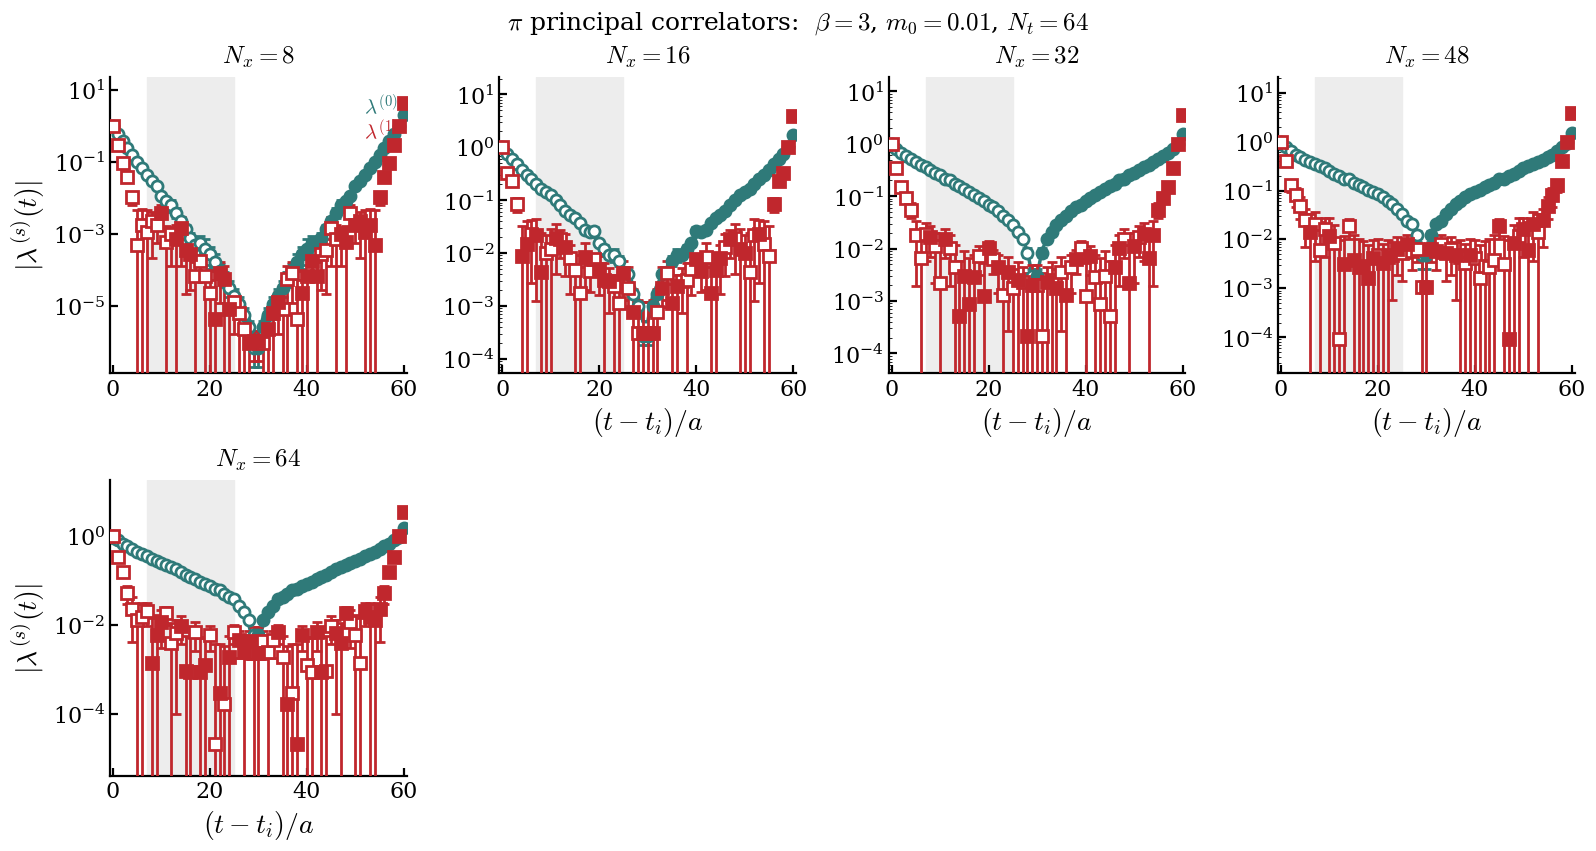

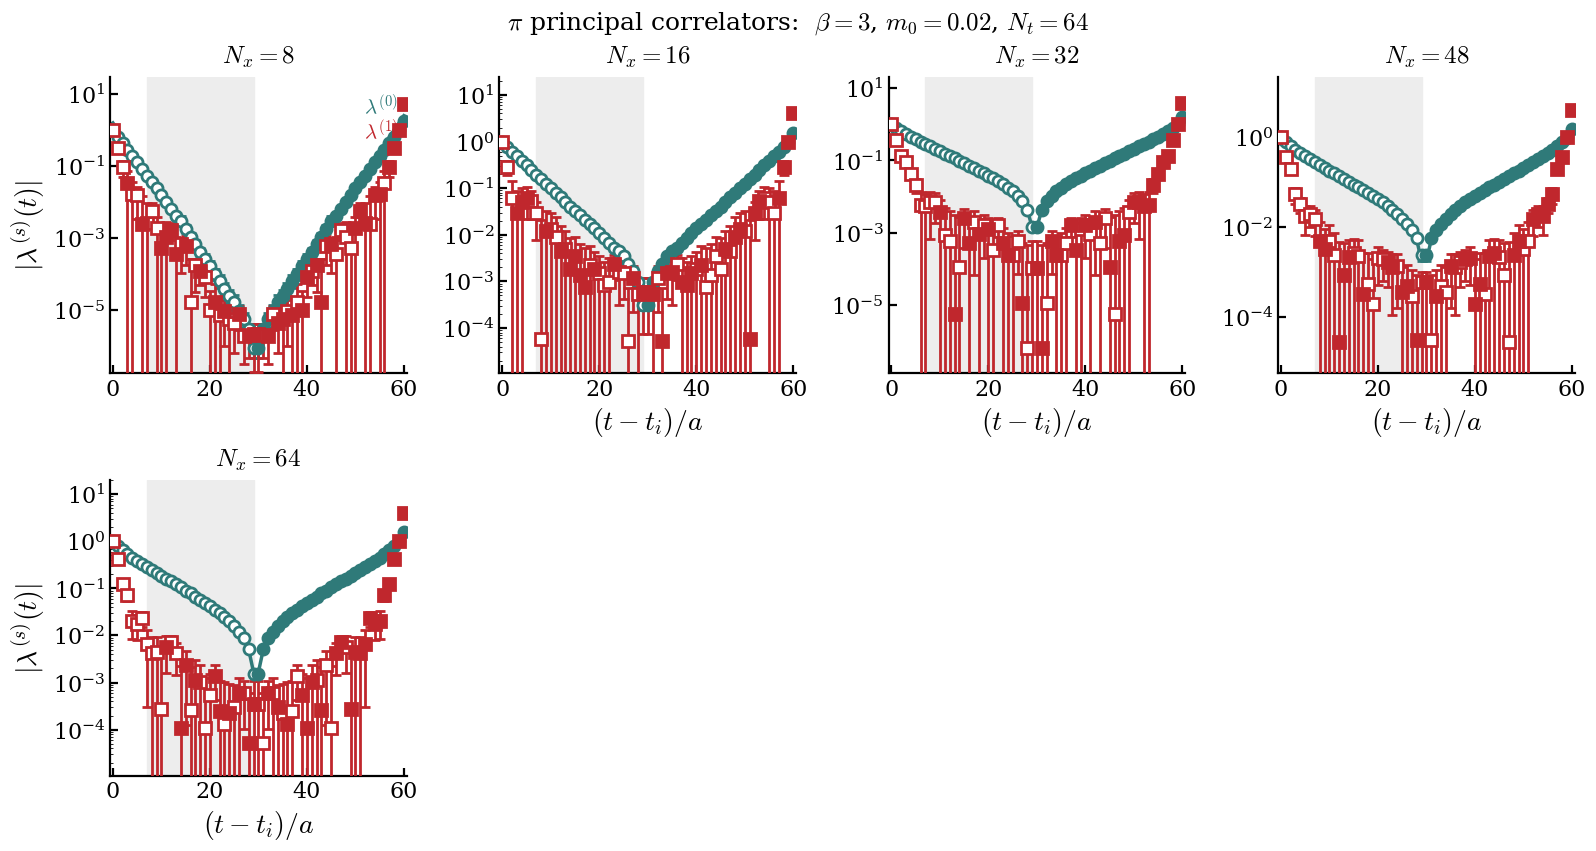

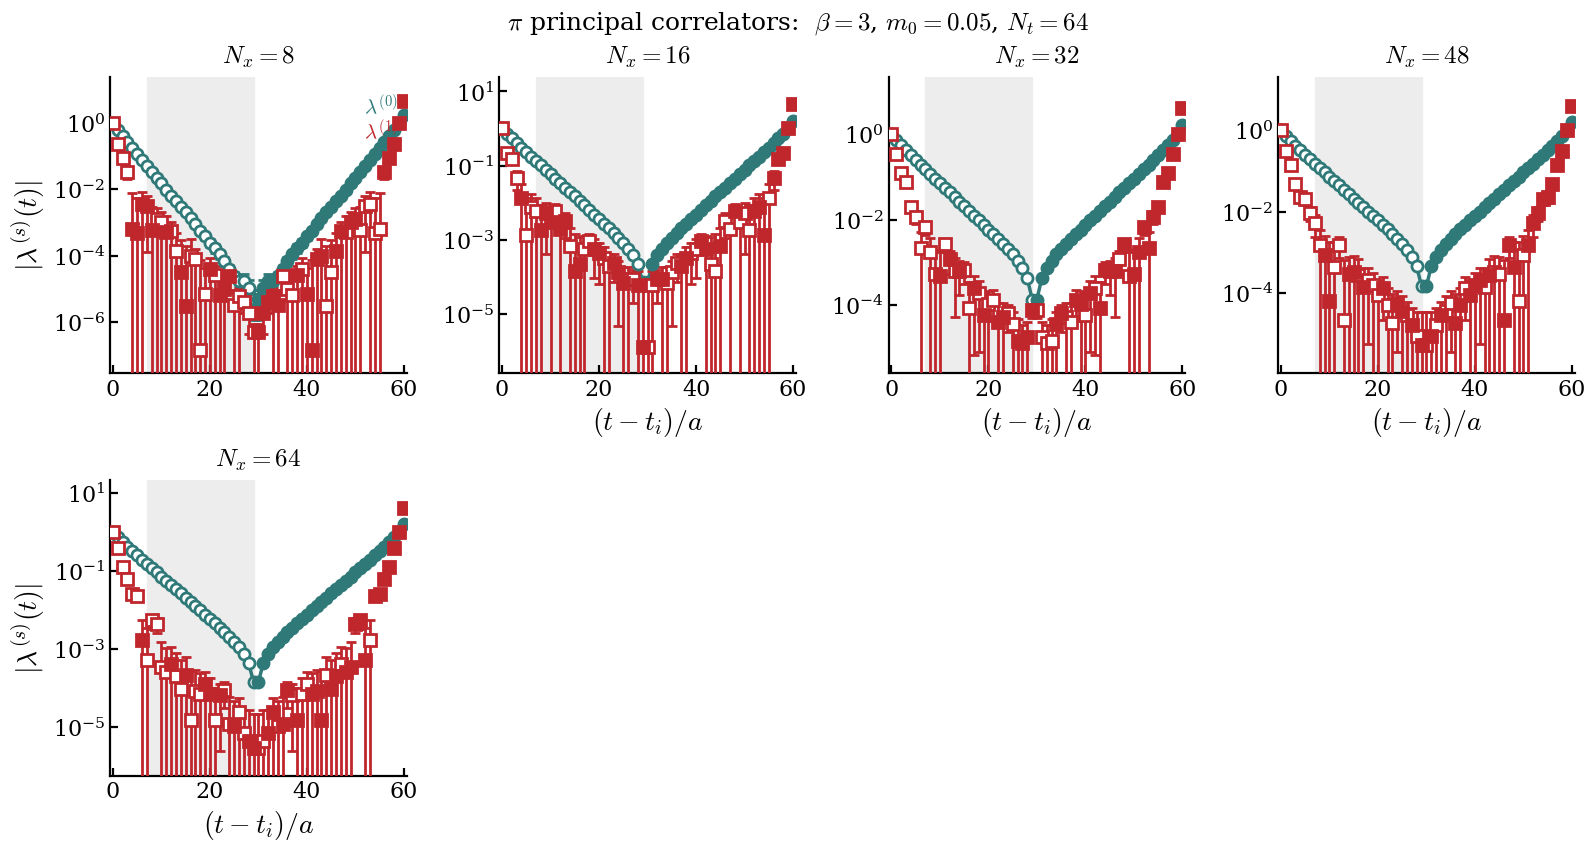

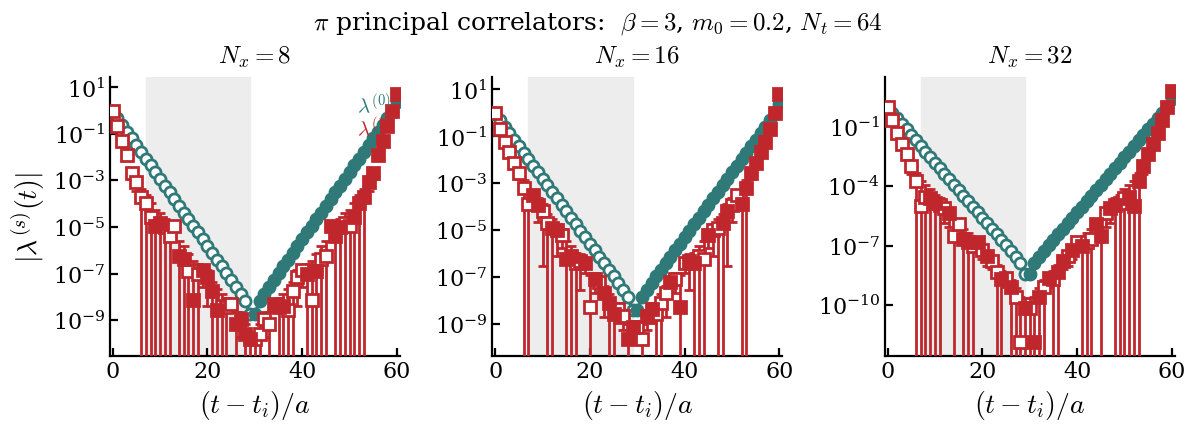

In [8]:
# raw principal correlators on a log axis, fitted sinh overlaid: straight
# where the ground state dominates; the sinh cusp shows as the dive at T/2.
# One figure per quark mass.
for m0 in m0s:
    sim.plotting.prinCorrelSemilog(
        pionPrinCorrels[m0],
        masses=pionMasses[m0],
        fitT=fitTs[m0],
        fitModel=fitModel,
        labels=[rf"$N_x = {m.dimx}$" for m in metas[m0]],
        title=rf"$\pi$ principal correlators:  $\beta = {beta:g}$, "
              rf"$m_0 = {m0}$, $N_t = {Nt}$",
        savePath=f"figs/pionPrinCorrelSemilog_beta{beta:g}_m{m0}_NxScan_Nt{Nt}.pdf")
    plt.show()

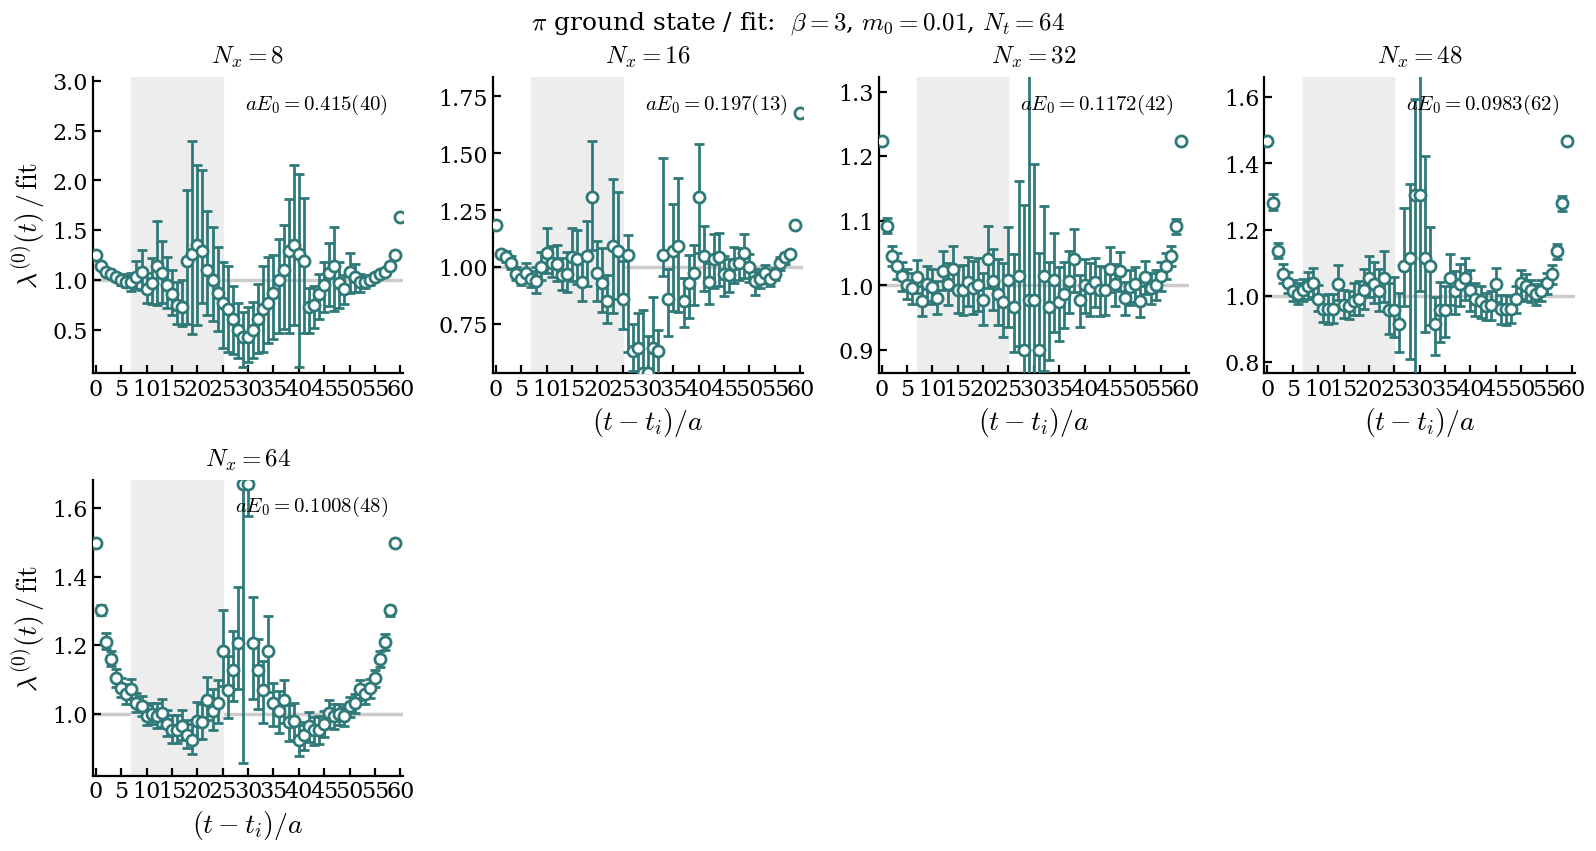

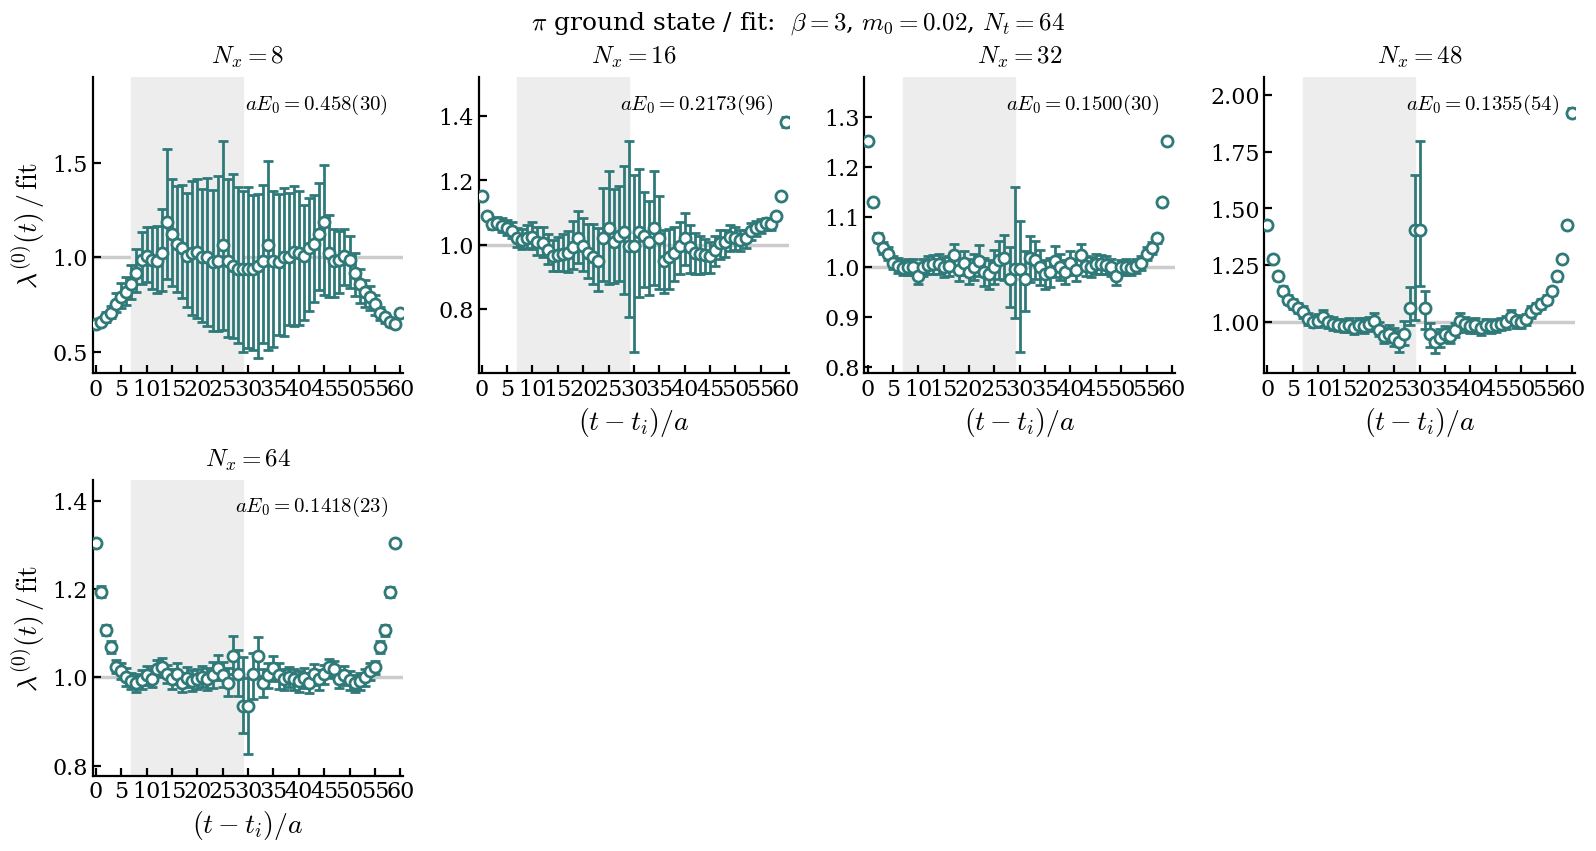

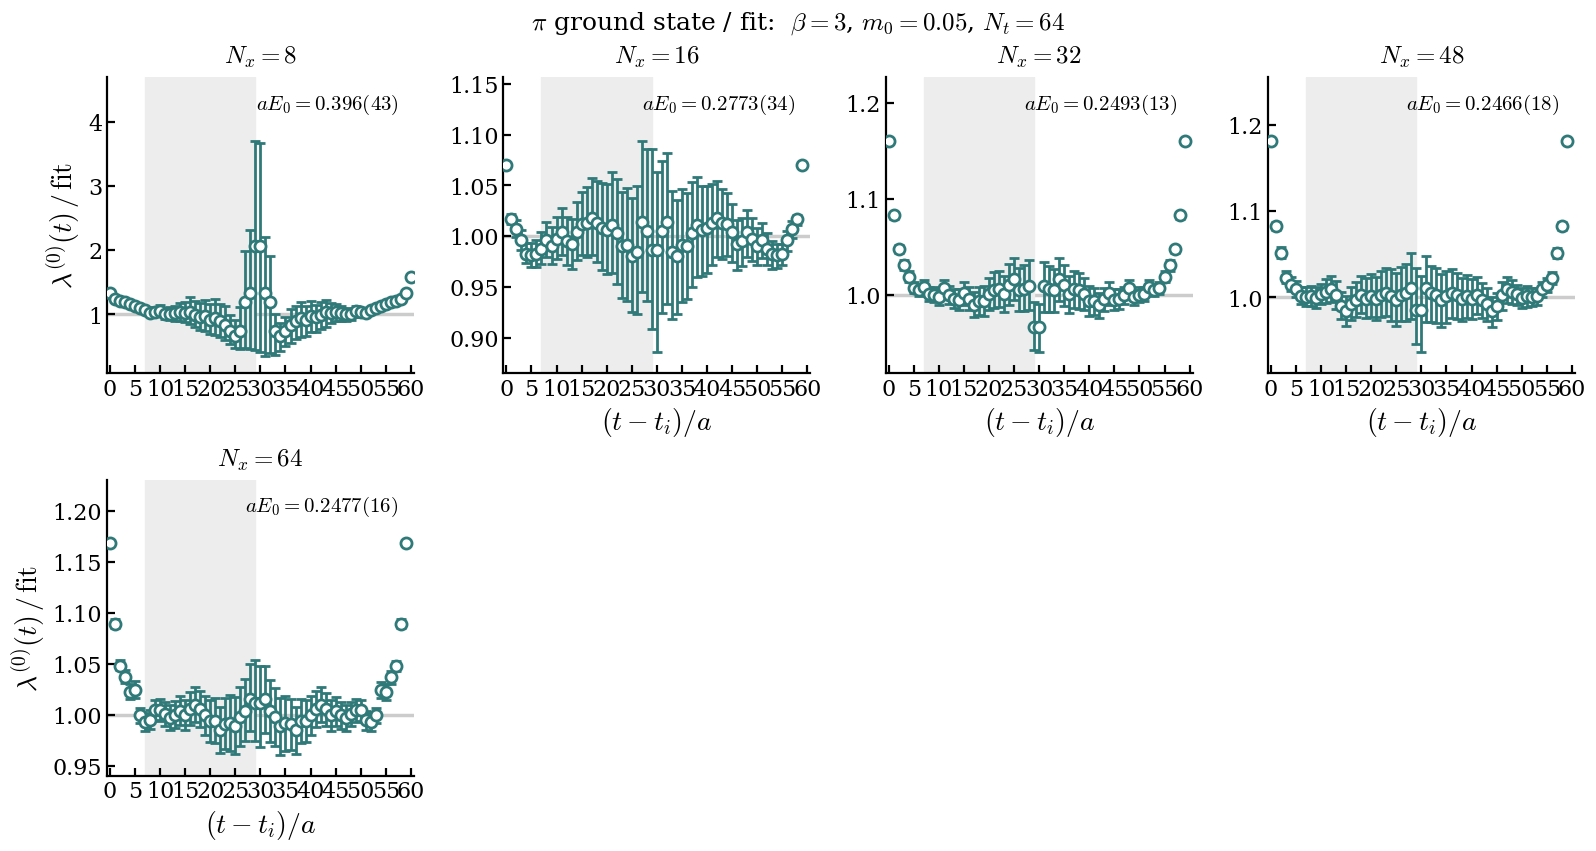

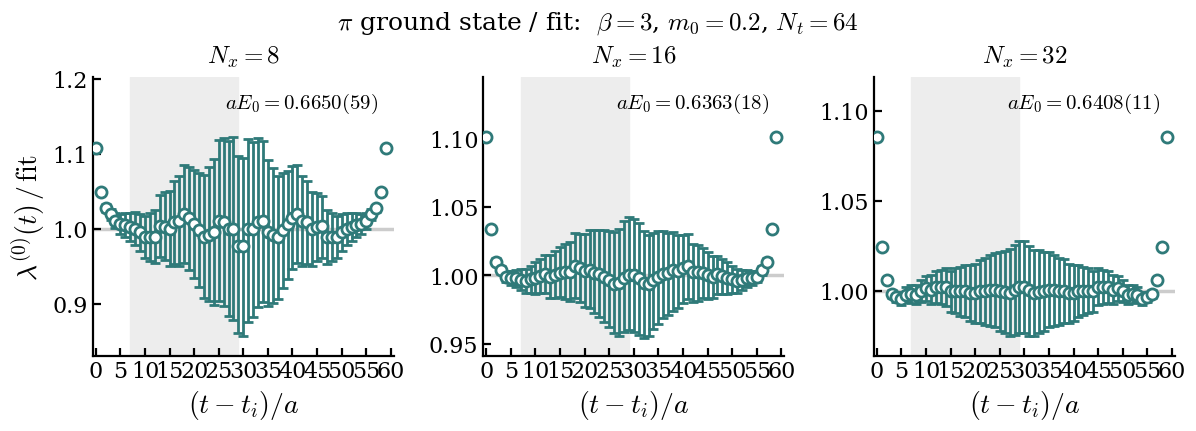

In [9]:
# fit quality per volume: lambda(t) / fit flattens to 1 wherever the sinh
# describes the data; deviations at small t are excited states, and points
# outside the shaded fit window carry no obligation to sit at 1.
# One figure per quark mass.
for m0 in m0s:
    sim.plotting.prinCorrelOverFit(
        pionPrinCorrels[m0], pionMasses[m0],
        state=0,
        fitT=fitTs[m0],
        fitModel=fitModel,
        labels=[rf"$N_x = {m.dimx}$" for m in metas[m0]],
        title=rf"$\pi$ ground state / fit:  $\beta = {beta:g}$, "
              rf"$m_0 = {m0}$, $N_t = {Nt}$",
        savePath=f"figs/pionPrinCorrelOverFit_beta{beta:g}_m{m0}_NxScan_Nt{Nt}.pdf")
    plt.show()

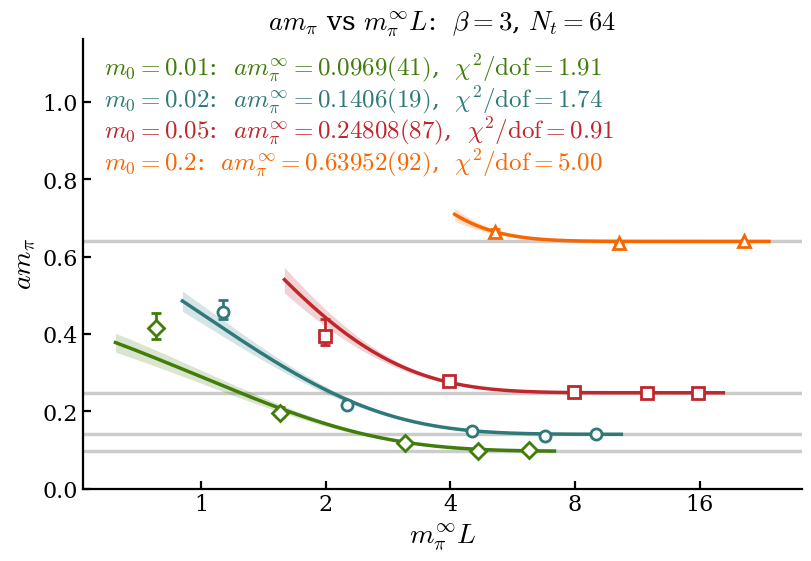

In [10]:
from scipy.optimize import curve_fit
from schwingerModel import plotting as sp

sp.setStyle()      # hand-rolled figure: apply the house style explicitly

# finite-volume fit per mass: m(L) = m_inf + A e^{-m_inf L}, self-consistent
# exponent; every mass on one axes for comparison. Each series is plotted
# against ITS OWN m_pi^inf * L, so equal x means equal physical box size.
def fvModel(L, mInf, A):
    return mInf + A * np.exp(-mInf * L)

massStyle = {"0.01": (sp.JLab_green, "D"), "0.02": (sp.JLab_blue, "o"),
             "0.05": (sp.JLab_red, "s"), "0.2":  (sp.JLab_orange, "^")}
fits = {}
fvChi2 = {}        # per-mass (chi2, dof) for the finite-volume fit, shown in the labels

fig, ax = plt.subplots(figsize=(8, 5.5), layout="constrained")

for m0 in m0s:
    color, marker = massStyle[m0]
    Ls = np.array([m.dimx for m in metas[m0]], dtype=float)
    aM = np.array([pm[0][0, 0] for pm in pionMasses[m0]])             # ground-state aE0
    errRows = np.array([pm[1][:, 0, 0] for pm in pionMasses[m0]]).T   # (2, n): [high-c, c-low]
    sigma = np.max(np.clip(errRows, 1e-12, None), axis=0)             # symmetrized for the fit

    popt, pcov = curve_fit(fvModel, Ls, aM, p0=(aM[-1], 1.0), sigma=sigma, absolute_sigma=True)
    mInf, dmInf = popt[0], np.sqrt(pcov[0, 0])
    fits[m0] = (popt, pcov)

    # same residuals the fit minimised, so chi2 matches what curve_fit saw
    fvChi2[m0] = (float((((aM - fvModel(Ls, *popt)) / sigma) ** 2).sum()), len(Ls) - 2)

    Lgrid = np.linspace(0.8 * Ls[0], 1.15 * Ls[-1], 400)
    draws = np.random.default_rng(0).multivariate_normal(popt, pcov, size=1000)
    bandLo, bandHi = np.percentile(np.array([fvModel(Lgrid, *d) for d in draws]), [16, 84], axis=0)

    ax.axhline(mInf, color=sp.GREY, lw=sp.LW, zorder=0)               # fitted asymptote
    ax.fill_between(mInf * Lgrid, bandLo, bandHi, color=color, alpha=0.20, lw=0, zorder=1)
    ax.plot(mInf * Lgrid, fvModel(Lgrid, *popt), color=color, lw=sp.LW, zorder=2)
    ax.errorbar(mInf * Ls, aM, yerr=np.clip(errRows, 0, None)[::-1],
                marker=marker, color=color, mec=color, **sp.eb_kw)

ax.set_xscale("log")
ax.set_xticks([1, 2, 4, 8, 16])
ax.set_xticklabels(["1", "2", "4", "8", "16"])
ax.minorticks_off()
# headroom: the labels now carry chi2/dof as well, and they sit top-left. 1.75x
# the largest point lifts the whole block clear of the m=0.2 curve, which is the
# highest thing on the axes (1.4x used to put the bottom label right on it).
ax.set_ylim(0, 1.75 * max(pm[0][0, 0] for m0 in m0s for pm in pionMasses[m0]))
ax.set_xlabel(r"$m_\pi^\infty L$")
ax.set_ylabel(r"$a m_\pi$")

# labels on the LEFT: every series flattens onto its asymptote at large
# m_pi^inf * L, so the plateaux all live on the right-hand side. With the extra
# headroom above they clear every curve vertically, so their width is free.
for j, m0 in enumerate(m0s):
    (popt, pcov), color = fits[m0], massStyle[m0][0]
    c2, dof = fvChi2[m0]
    ax.text(0.03, 0.90 - 0.070 * j,
            rf"$m_0 = {m0}$:  $a m_\pi^\infty = {sp.fmtErr(popt[0], np.sqrt(pcov[0, 0]))}$,  "
            rf"$\chi^2/\mathrm{{dof}} = {c2 / dof:.2f}$",
            color=color, ha="left", va="bottom", transform=ax.transAxes,
            fontsize=18, zorder=5, bbox=sp.TEXTBOX)

ax.set_title(rf"$am_\pi$ vs $m_\pi^\infty L$:  $\beta = {beta:g}$, $N_t = {Nt}$")

fig.savefig(f"figs/pionMassVsMpiL_beta{beta:g}_m{'-'.join(m0s)}_Nt{Nt}.pdf")

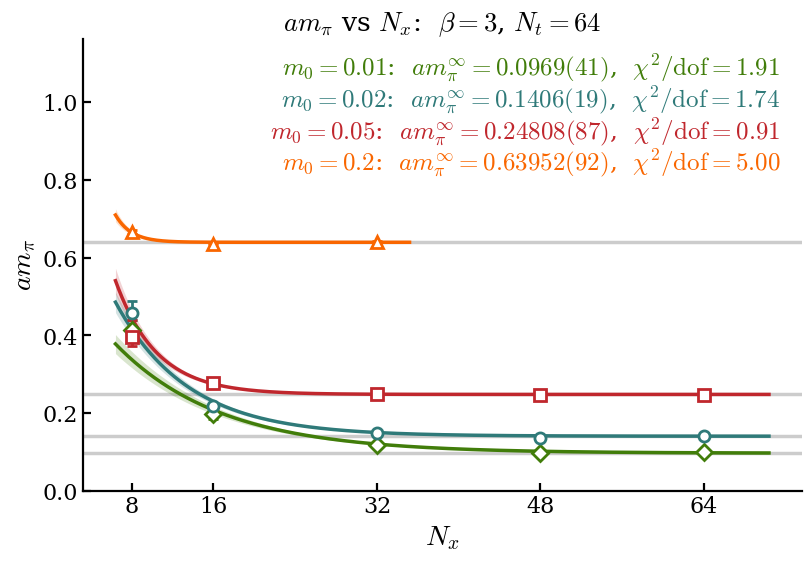

In [11]:
# Same fits, x-axis in lattice sites: the masses share x positions wherever they
# share a volume, so this view compares the raw boxes directly (the mpi*L view
# answers "how converged", this one answers "which box do I need"). Reuses `fits`
# and `fvChi2` from the cell above — run that first.
fig, ax = plt.subplots(figsize=(8, 5.5), layout="constrained")

for m0 in m0s:
    color, marker = massStyle[m0]
    Ls = np.array([m.dimx for m in metas[m0]], dtype=float)
    aM = np.array([pm[0][0, 0] for pm in pionMasses[m0]])
    errRows = np.array([pm[1][:, 0, 0] for pm in pionMasses[m0]]).T

    popt, pcov = fits[m0]
    mInf = popt[0]

    Lgrid = np.linspace(0.8 * Ls[0], 1.1 * Ls[-1], 400)
    draws = np.random.default_rng(0).multivariate_normal(popt, pcov, size=1000)
    bandLo, bandHi = np.percentile(np.array([fvModel(Lgrid, *d) for d in draws]), [16, 84], axis=0)

    ax.axhline(mInf, color=sp.GREY, lw=sp.LW, zorder=0)              # fitted asymptote
    ax.fill_between(Lgrid, bandLo, bandHi, color=color, alpha=0.20, lw=0, zorder=1)
    ax.plot(Lgrid, fvModel(Lgrid, *popt), color=color, lw=sp.LW, zorder=2)
    ax.errorbar(Ls, aM, yerr=np.clip(errRows, 0, None)[::-1],
                marker=marker, color=color, mec=color, **sp.eb_kw)

ax.set_xticks(sorted({Nx for m0 in m0s for Nx in Nxs[m0]}))
# same headroom as the mpi*L view, for the same reason: the labels grew a
# chi2/dof column and have to clear the m=0.2 curve
ax.set_ylim(0, 1.75 * max(pm[0][0, 0] for m0 in m0s for pm in pionMasses[m0]))
ax.set_xlabel(r"$N_x$")
ax.set_ylabel(r"$a m_\pi$")

for j, m0 in enumerate(m0s):
    (popt, pcov), color = fits[m0], massStyle[m0][0]
    c2, dof = fvChi2[m0]
    ax.text(0.97, 0.90 - 0.07 * j,
            rf"$m_0 = {m0}$:  $a m_\pi^\infty = {sp.fmtErr(popt[0], np.sqrt(pcov[0, 0]))}$,  "
            rf"$\chi^2/\mathrm{{dof}} = {c2 / dof:.2f}$",
            color=color, ha="right", va="bottom", transform=ax.transAxes,
            fontsize=18, zorder=5, bbox=sp.TEXTBOX)

ax.set_title(rf"$am_\pi$ vs $N_x$:  $\beta = {beta:g}$, $N_t = {Nt}$")

fig.savefig(f"figs/pionMassVsNx_beta{beta:g}_m{'-'.join(m0s)}_Nt{Nt}.pdf")

m0 =  0.01:  a m_pi^inf =   0.0969(41)   m_pi^2 / m0 = 0.939   fv chi2/dof = 1.91
m0 =  0.02:  a m_pi^inf =   0.1406(19)   m_pi^2 / m0 = 0.989   fv chi2/dof = 1.74
m0 =  0.05:  a m_pi^inf =  0.24808(87)   m_pi^2 / m0 = 1.231   fv chi2/dof = 0.91
m0 =   0.2:  a m_pi^inf =  0.63952(92)   m_pi^2 / m0 = 2.045   fv chi2/dof = 5.00

power law  m_pi ~ m0^p
   all four masses:   p =   0.6775(25)   chi2/dof =   13.7  (2 dof)
   m0 <= 0.05:        p =    0.611(13)   chi2/dof =    1.4  (1 dof)
effective two-point slopes:  0.01->0.02: 0.537,  0.02->0.05: 0.619,  0.05->0.2: 0.683
m_pi^2/m0 is not constant and the slopes drift, which is why the GMOR
p = 1/2 reference was dropped from the figure; pinning the small-mass
exponent needs the m0 = 0.01 asymptote at larger volumes.


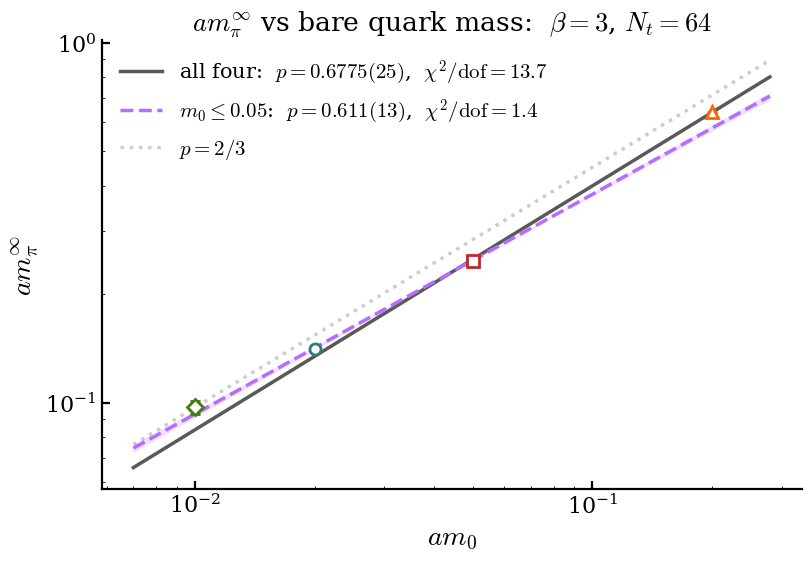

In [12]:
# Chiral behaviour: the infinite-volume pion mass against the BARE quark mass.
# No residual-mass correction — with domain wall at N5=16 the true quark mass is
# m0 + m_res, so every point sits at slightly too small an x. Until m_res is
# measured (PCAC), read the exponent below as a lower bound on the truth: a
# positive m_res lifts the light points most, which flattens the apparent slope.
# Reuses `fits` from the m_pi-vs-L cell above — run that first.
m0Vals = np.array([float(m0) for m0 in m0s])
mInfs  = np.array([fits[m0][0][0] for m0 in m0s])
dmInfs = np.array([np.sqrt(fits[m0][1][0, 0]) for m0 in m0s])

# power law m_pi = C m0^p, fitted in log space so the errors enter as relative
def logPowerLaw(m, logC, p):
    return logC + p * np.log(m)


def fitPowerLaw(mask):
    """Log-space power-law fit over the masked subset; returns (popt, pcov, chi2, dof)."""
    opt, cov = curve_fit(logPowerLaw, m0Vals[mask], np.log(mInfs[mask]),
                         sigma=(dmInfs / mInfs)[mask], absolute_sigma=True, p0=(0.0, 2/3))
    c2 = float((((np.log(mInfs[mask]) - logPowerLaw(m0Vals[mask], *opt))
                 / (dmInfs / mInfs)[mask]) ** 2).sum())
    return opt, cov, c2, int(mask.sum()) - 2


allMask   = np.ones_like(m0Vals, dtype=bool)
lightMask = m0Vals <= 0.05          # drop m0 = 0.2, the point off the small-mass end

pOpt, pCov, chi2, dof = fitPowerLaw(allMask)
pExp, dpExp = pOpt[1], np.sqrt(pCov[1, 1])

pOptL, pCovL, chi2L, dofL = fitPowerLaw(lightMask)
pExpL, dpExpL = pOptL[1], np.sqrt(pCovL[1, 1])


def band(opt, cov):
    d = np.random.default_rng(0).multivariate_normal(opt, cov, size=1000)
    return np.percentile(np.array([np.exp(logPowerLaw(mGrid, *x)) for x in d]), [16, 84], axis=0)


mGrid = np.logspace(np.log10(0.7 * m0Vals[0]), np.log10(1.4 * m0Vals[-1]), 400)
bandLo, bandHi = band(pOpt, pCov)
bandLoL, bandHiL = band(pOptL, pCovL)

# log-log, where a power law is a straight line and the exponent is the slope.
# Two fits: all four masses (solid grey), and the three light ones with m0 = 0.2
# dropped (dashed violet) — m0 = 0.2 is almost certainly outside the small-mass
# regime, and it carries ~84% of the weight, so it drags the single-power-law
# exponent. The light-only line is drawn across the full range on purpose: where
# it peels away from the m0 = 0.2 point is the visual statement that one
# exponent does not cover this range.
# One reference, anchored at the lightest point: p = 2/3, the small-mass
# expectation for the 2-flavour Schwinger model — which is the theory the
# isotriplet basis above is measuring. The GMOR p = 1/2 line and the m_pi^2
# GMOR-test panel that used to sit beside this one are gone: GMOR is the wrong
# theory here, and the numbers below (m_pi^2/m0 far from constant, two-point
# slopes drifting well above 1/2) are what ruled it out.
# The legend sits upper-left, which is empty on a log-log rising line.
fig, ax = plt.subplots(figsize=(8, 5.5), layout="constrained")

ax.fill_between(mGrid, bandLo, bandHi, color=sp.GREY, alpha=0.45, lw=0, zorder=1)
ax.plot(mGrid, np.exp(logPowerLaw(mGrid, *pOpt)), color="0.35", lw=sp.LW, zorder=2,
        label=rf"all four:  $p = {sp.fmtErr(pExp, dpExp)}$,  "
              rf"$\chi^2/\mathrm{{dof}} = {chi2 / dof:.1f}$")

ax.fill_between(mGrid, bandLoL, bandHiL, color=sp.lavender_violet, alpha=0.20, lw=0, zorder=1)
ax.plot(mGrid, np.exp(logPowerLaw(mGrid, *pOptL)), color=sp.lavender_violet, ls="--",
        lw=sp.LW, zorder=3,
        label=rf"$m_0 \leq 0.05$:  $p = {sp.fmtErr(pExpL, dpExpL)}$,  "
              rf"$\chi^2/\mathrm{{dof}} = {chi2L / dofL:.1f}$")

ax.plot(mGrid, mInfs[0] * (mGrid / m0Vals[0]) ** (2/3), ls=":", color=sp.GREY,
        lw=sp.LW, zorder=0, label=r"$p = 2/3$")
for i, m0 in enumerate(m0s):
    color, marker = massStyle[m0]
    ax.errorbar(m0Vals[i], mInfs[i], yerr=dmInfs[i], marker=marker,
                color=color, mec=color, **sp.eb_kw)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$a m_0$")
ax.set_ylabel(r"$a m_\pi^\infty$")
ax.legend(loc="upper left", fontsize=15, frameon=False)
ax.set_title(rf"$a m_\pi^\infty$ vs bare quark mass:  $\beta = {beta:g}$, $N_t = {Nt}$")

fig.savefig(f"figs/pionMassVsQuarkMass_beta{beta:g}_m{'-'.join(m0s)}_Nt{Nt}.pdf")

for m0, mI, dmI in zip(m0s, mInfs, dmInfs):
    print(f"m0 = {m0:>5}:  a m_pi^inf = {sp.fmtErr(mI, dmI):>12}   "
          f"m_pi^2 / m0 = {mI**2/float(m0):.3f}   "
          f"fv chi2/dof = {fvChi2[m0][0] / fvChi2[m0][1]:.2f}")

print(f"\npower law  m_pi ~ m0^p")
print(f"   all four masses:   p = {sp.fmtErr(pExp, dpExp):>12}   "
      f"chi2/dof = {chi2/dof:6.1f}  ({dof} dof)")
print(f"   m0 <= 0.05:        p = {sp.fmtErr(pExpL, dpExpL):>12}   "
      f"chi2/dof = {chi2L/dofL:6.1f}  ({dofL} dof)")
print("effective two-point slopes:  " + ",  ".join(
    f"{m0s[i]}->{m0s[i+1]}: {np.log(mInfs[i+1]/mInfs[i])/np.log(m0Vals[i+1]/m0Vals[i]):.3f}"
    for i in range(len(m0s) - 1)))
# The drift in those two-point slopes is why the all-four chi2/dof is large: one
# exponent does not cover 0.01 -> 0.2. Take either p as an average over ITS range,
# NOT a measurement of the chiral exponent, and the quoted errors as statistics only.
print("m_pi^2/m0 is not constant and the slopes drift, which is why the GMOR\n"
      "p = 1/2 reference was dropped from the figure; pinning the small-mass\n"
      "exponent needs the m0 = 0.01 asymptote at larger volumes.")